# MuJoCo Basics

## Learning Objectives

- Load a MuJoCo model from XML (both from file and from dms assets)
- Understand the key data structures: `MjModel` and `MjData`
- Inspect model properties: bodies, joints, degrees of freedom
- Set initial conditions (`qpos`, `qvel`) and step the simulation
- Read sensor data and extract state information
- Render frames and create videos of simulations
- Apply external forces and torques to bodies

## What is MuJoCo?

MuJoCo (Multi-Joint dynamics with Contact) is a physics engine designed for simulating articulated bodies -- robots, mechanisms, and biomechanical systems. It is fast, accurate, and widely used in robotics and reinforcement learning research.

A MuJoCo simulation has two main objects:
- **`MjModel`**: The static description of the system (geometry, masses, joint types, etc.). Created once from an XML file.
- **`MjData`**: The dynamic state (positions, velocities, forces, sensor readings, etc.). Updated at every simulation step.

## Section 1: Loading a Model

MuJoCo models are defined in XML files (MJCF format). The `dms` package bundles several models that we can load by name using `dms.get_asset_path()`.

In [1]:
import numpy as np
import mujoco
import matplotlib.pyplot as plt
import mediapy as media
import dms

# Load the pendulum model from dms assets
model_path = dms.get_asset_path("mujoco_models/pendulum.xml")
print(f"Model path: {model_path}")

model = mujoco.MjModel.from_xml_path(model_path)
data = mujoco.MjData(model)

print(f"Model loaded: {model.nq} position DOFs, {model.nv} velocity DOFs")
print(f"Timestep: {model.opt.timestep} s")
print(f"Gravity: {model.opt.gravity}")

Model path: C:\git\dynamics_of_mechanical_systems\src\dms\assets\mujoco_models\pendulum.xml
Model loaded: 1 position DOFs, 1 velocity DOFs
Timestep: 0.001 s
Gravity: [ 0.    0.   -9.81]


## Section 2: Inspecting the Model

The model contains all the static information about the system: how many bodies, joints, and sensors it has, what types they are, and their physical parameters.

Key properties:
- `model.nq` -- number of generalized position coordinates
- `model.nv` -- number of generalized velocity coordinates (can differ from `nq` for quaternion joints)
- `model.nbody` -- number of bodies (including the world body)
- `model.njnt` -- number of joints
- `model.nsensor` -- number of sensors

In [2]:
print("=== Model Summary ===")
print(f"Bodies:  {model.nbody}")
print(f"Joints:  {model.njnt}")
print(f"DOFs:    nq={model.nq}, nv={model.nv}")
print(f"Sensors: {model.nsensor}")
print()

# List all bodies
print("--- Bodies ---")
for i in range(model.nbody):
    name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_BODY, i) or "(world)"
    print(f"  [{i}] {name}")

# List all joints
print("\n--- Joints ---")
for i in range(model.njnt):
    name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, i)
    jnt_type = ["free", "ball", "slide", "hinge"][model.jnt_type[i]]
    print(f"  [{i}] {name} (type: {jnt_type})")

# List all sensors
print("\n--- Sensors ---")
for i in range(model.nsensor):
    name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_SENSOR, i)
    print(f"  [{i}] {name}")

=== Model Summary ===
Bodies:  2
Joints:  1
DOFs:    nq=1, nv=1
Sensors: 0

--- Bodies ---
  [0] world
  [1] link

--- Joints ---
  [0] hinge (type: hinge)

--- Sensors ---


## Section 3: State Vectors -- qpos and qvel

The state of a MuJoCo system is stored in two arrays inside `MjData`:

- **`data.qpos`** -- generalized positions (joint angles for hinges, displacements for slides)
- **`data.qvel`** -- generalized velocities (angular velocities, linear velocities)

For the simple pendulum, both are 1D: one hinge angle and one angular velocity.

You can set these directly to define initial conditions.

In [3]:
# Reset the simulation to its default state
mujoco.mj_resetData(model, data)
print(f"Default state:  qpos={data.qpos}, qvel={data.qvel}")

# Set initial conditions: start the pendulum at 90 degrees
data.qpos[0] = np.pi / 2  # 90 degrees
data.qvel[0] = 0.0         # starting from rest
mujoco.mj_forward(model, data)  # compute derived quantities (e.g. body positions)
print(f"After setting:  qpos={data.qpos}, qvel={data.qvel}")
print(f"Simulation time: {data.time:.3f} s")

Default state:  qpos=[0.], qvel=[0.]
After setting:  qpos=[1.57079633], qvel=[0.]
Simulation time: 0.000 s


## Section 4: Stepping the Simulation

Each call to `mujoco.mj_step(model, data)` advances the simulation by one timestep. The timestep is defined in the XML (`<option timestep="0.002"/>`).

Let's simulate the pendulum for 5 seconds and record its trajectory.

In [4]:
# Reset and set initial conditions
mujoco.mj_resetData(model, data)
data.qpos[0] = np.pi / 4
mujoco.mj_forward(model, data)

duration = 5.0  # seconds
dt = model.opt.timestep

# Storage
times = []
positions = []
velocities = []

while data.time < duration:
    times.append(data.time)
    positions.append(data.qpos[0].copy())
    velocities.append(data.qvel[0].copy())
    mujoco.mj_step(model, data)

times = np.array(times)
positions = np.array(positions)
velocities = np.array(velocities)

print(f"Simulated {len(times)} steps ({times[-1]:.1f} s)")
print(f"Final angle: {positions[-1]:.4f} rad")
print(f"Final velocity: {velocities[-1]:.4f} rad/s")

Simulated 5000 steps (5.0 s)
Final angle: 2.0147 rad
Final velocity: 0.7166 rad/s


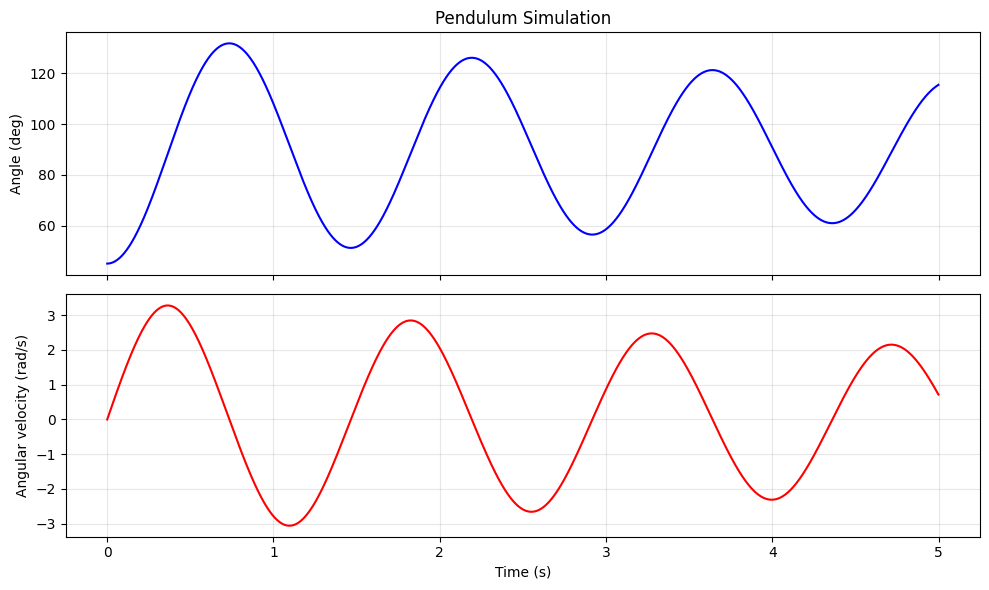

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(times, np.degrees(positions), 'b-', linewidth=1.5)
axes[0].set_ylabel('Angle (deg)')
axes[0].set_title('Pendulum Simulation')
axes[0].grid(True, alpha=0.3)

axes[1].plot(times, velocities, 'r-', linewidth=1.5)
axes[1].set_ylabel('Angular velocity (rad/s)')
axes[1].set_xlabel('Time (s)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 5: Reading Sensor Data

MuJoCo models can include sensors (defined in the XML). Sensor values are stored in `data.sensordata` and updated automatically at each step.

The pendulum model has one sensor: `theta`, which measures the hinge joint angle.

In [6]:
# Reset and simulate a few steps
mujoco.mj_resetData(model, data)
data.qpos[0] = 1.0
mujoco.mj_forward(model, data)

print(f"qpos[0] = {data.qpos[0]:.4f}")
print(f"sensordata = {data.sensordata}")
print()

# Sensors by name: find the sensor address and dimension
for i in range(model.nsensor):
    name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_SENSOR, i)
    adr = model.sensor_adr[i]
    dim = model.sensor_dim[i]
    val = data.sensordata[adr:adr+dim]
    print(f"Sensor '{name}': address={adr}, dim={dim}, value={val}")

qpos[0] = 1.0000
sensordata = []



## Section 6: Rendering

MuJoCo can render scenes to images. We create a `Renderer`, update the scene, and call `render()` to get a NumPy array of pixels.

We can render from a named camera (defined in the XML) or use the default free camera.

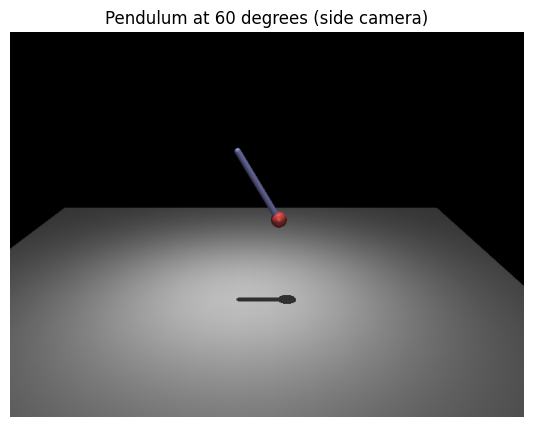

Frame shape: (480, 640, 3) (height x width x RGB)


In [7]:
renderer = mujoco.Renderer(model, height=480, width=640)

# Reset and set an interesting pose
mujoco.mj_resetData(model, data)
data.qpos[0] = np.pi / 3  # 60 degrees
mujoco.mj_forward(model, data)

# Render from the "side" camera defined in the XML
renderer.update_scene(data, dms.mujoco.make_camera(model))
frame = renderer.render()

plt.figure(figsize=(8, 5))
plt.imshow(frame)
plt.axis('off')
plt.title('Pendulum at 60 degrees (side camera)')
plt.show()
print(f"Frame shape: {frame.shape} (height x width x RGB)")
renderer.close()

## Section 7: Creating a Video

To make a video, we capture frames at a fixed framerate during the simulation loop. The `mediapy` library makes it easy to display videos inline in Jupyter.

In [ ]:
# Reset and set initial conditions
mujoco.mj_resetData(model, data)
data.qpos[0] = np.pi / 4
mujoco.mj_forward(model, data)

duration = 5.0
framerate = 30  # frames per second for the video
frames = []
renderer = mujoco.Renderer(model, height=480, width=640)
cam=dms.mujoco.make_camera(model)
while data.time < duration:
    # Capture frame at the desired framerate
    if len(frames) < data.time * framerate:
        renderer.update_scene(data, camera=cam)
        frames.append(renderer.render().copy())
    mujoco.mj_step(model, data)
renderer.close()
print(f"Captured {len(frames)} frames ({duration} s at {framerate} fps)")
media.show_video(frames, fps=framerate)

Captured 150 frames (5.0 s at 30 fps)


This browser does not support the video tag.


## Section 8: Applying Forces

You can apply external forces and torques to bodies using `data.xfrc_applied`. This is a `(nbody, 6)` array where each row is `[fx, fy, fz, tx, ty, tz]` -- a force/torque pair in world coordinates applied at the body's center of mass.

Let's give the pendulum a kick by applying a torque.

In [ ]:
# Reset to hanging straight down (equilibrium)
mujoco.mj_resetData(model, data)
mujoco.mj_forward(model, data)

duration = 20.0
kick_duration = 0.5  # apply force for 0.5 seconds

# Find the body ID for the pendulum
body_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "pendulum")
print(f"Pendulum body ID: {body_id}")
renderer = mujoco.Renderer(model, height=480, width=640)
cam=dms.mujoco.make_camera(model)
times_f = []
positions_f = []
frames_f = []

while data.time < duration:
    # Apply a torque around the Y axis for the kick duration
    if data.time < kick_duration:
        data.xfrc_applied[body_id] = [0, 0, 0, 0, 100.0, 0]  # torque_y = 100 Nm
    else:
        data.xfrc_applied[body_id] = [0, 0, 0, 0, 0, 0]

    times_f.append(data.time)
    positions_f.append(data.qpos[0].copy())

    if len(frames_f) < data.time * 30:
        renderer.update_scene(data, camera=cam)
        frames_f.append(renderer.render().copy())

    mujoco.mj_step(model, data)
renderer.close()
print(f"Applied 20 Nm torque for {kick_duration} s, then free swing")
media.show_video(frames_f, fps=30)

Pendulum body ID: -1
Applied 20 Nm torque for 0.5 s, then free swing


This browser does not support the video tag.


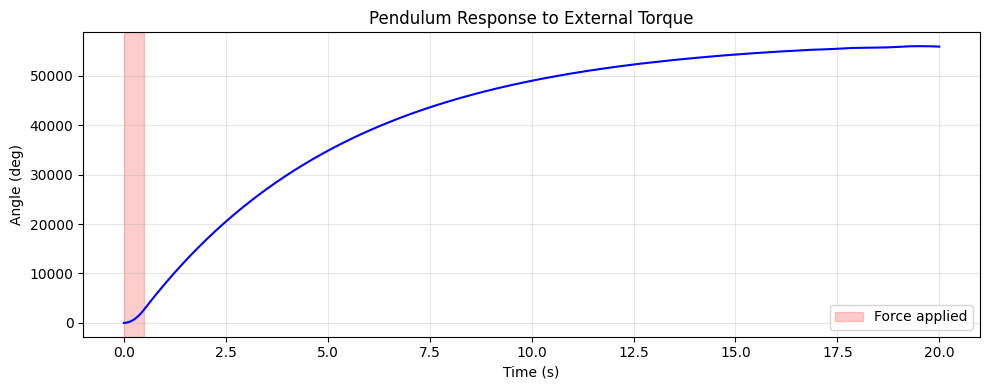

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(times_f, np.degrees(positions_f), 'b-', linewidth=1.5)
plt.axvspan(0, kick_duration, alpha=0.2, color='red', label='Force applied')
plt.xlabel('Time (s)')
plt.ylabel('Angle (deg)')
plt.title('Pendulum Response to External Torque')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 9: Loading Other Models

The `dms` package includes several bundled models. Let's load the double pendulum and simulate it.

In [11]:
# Load the double pendulum
dp_model = mujoco.MjModel.from_xml_path(dms.get_asset_path("mujoco_models/double_pendulum.xml"))
dp_data = mujoco.MjData(dp_model)
dp_renderer = mujoco.Renderer(dp_model, height=480, width=640)

print(f"Double pendulum: nq={dp_model.nq}, nv={dp_model.nv}")
print(f"Joints:")
for i in range(dp_model.njnt):
    name = mujoco.mj_id2name(dp_model, mujoco.mjtObj.mjOBJ_JOINT, i)
    print(f"  [{i}] {name}")

# Set initial conditions: both links at 90 degrees
mujoco.mj_resetData(dp_model, dp_data)
dp_data.qpos[0] = np.pi / 2  # first joint
dp_data.qpos[1] = np.pi / 4  # second joint
mujoco.mj_forward(dp_model, dp_data)
renderer=mujoco.Renderer(dp_model, height=480, width=640)
# Simulate and record
duration = 10.0
dp_times = []
dp_q1 = []
dp_q2 = []
dp_frames = []

while dp_data.time < duration:
    dp_times.append(dp_data.time)
    dp_q1.append(dp_data.qpos[0].copy())
    dp_q2.append(dp_data.qpos[1].copy())
    if len(dp_frames) < dp_data.time * 30:
        dp_renderer.update_scene(dp_data)
        dp_frames.append(dp_renderer.render().copy())
    mujoco.mj_step(dp_model, dp_data)

renderer.close()
media.show_video(dp_frames, fps=30)

Double pendulum: nq=2, nv=2
Joints:
  [0] hinge1
  [1] hinge2


This browser does not support the video tag.


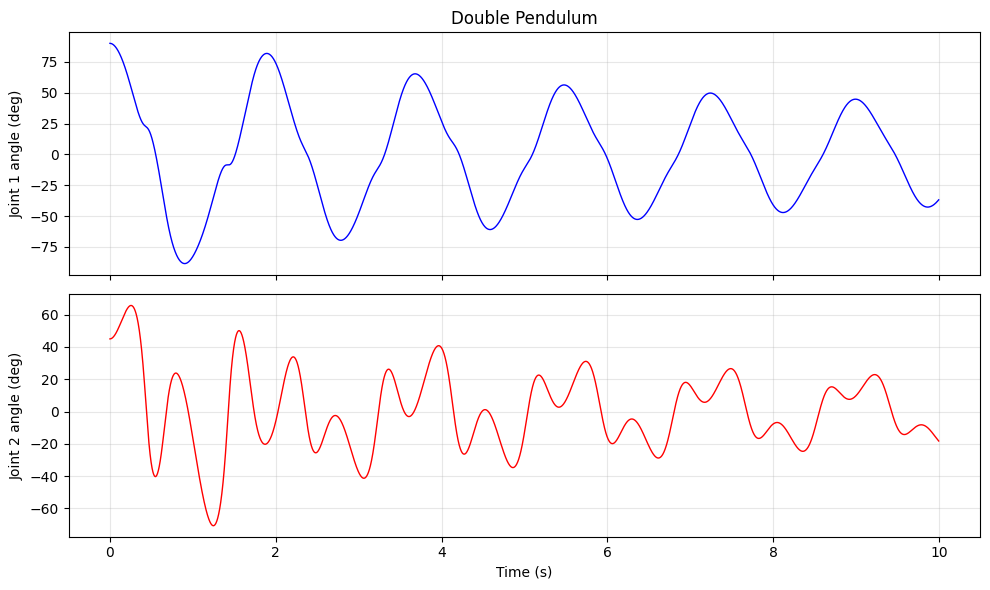

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(dp_times, np.degrees(dp_q1), 'b-', linewidth=1)
axes[0].set_ylabel('Joint 1 angle (deg)')
axes[0].set_title('Double Pendulum')
axes[0].grid(True, alpha=0.3)

axes[1].plot(dp_times, np.degrees(dp_q2), 'r-', linewidth=1)
axes[1].set_ylabel('Joint 2 angle (deg)')
axes[1].set_xlabel('Time (s)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 10: Energy and the Mass Matrix

MuJoCo gives you access to important physical quantities:

- **`data.energy`** -- `[potential_energy, kinetic_energy]` (requires `<option flag="energy"/>` or we compute it manually)
- **Mass matrix** -- the generalized inertia matrix $M(q)$, computed with `mujoco.mj_fullM()`

The mass matrix relates generalized forces to accelerations: $\tau = M(q)\ddot{q} + c(q, \dot{q})$

In [ ]:
# Use the double pendulum to show the mass matrix
mujoco.mj_resetData(dp_model, dp_data)
dp_data.qpos[0] = np.pi / 4
dp_data.qpos[1] = np.pi / 6
mujoco.mj_forward(dp_model, dp_data)

# Compute the full mass matrix
M = np.zeros((dp_model.nv, dp_model.nv))
mujoco.mj_fullM(dp_model, M, dp_data.qM)

print("Mass matrix M(q):")
print(M)
print(f"\nShape: {M.shape}")
print(f"Symmetric: {np.allclose(M, M.T)}")
print(f"Positive definite: {np.all(np.linalg.eigvals(M) > 0)}")
print(f"\nBias forces (Coriolis + gravity): {dp_data.qfrc_bias}")

## Summary

| Concept | API |
|---|---|
| Load model | `mujoco.MjModel.from_xml_path(path)` |
| Create data | `mujoco.MjData(model)` |
| Reset state | `mujoco.mj_resetData(model, data)` |
| Set positions | `data.qpos[:] = ...` |
| Set velocities | `data.qvel[:] = ...` |
| Compute derived quantities | `mujoco.mj_forward(model, data)` |
| Step simulation | `mujoco.mj_step(model, data)` |
| Read sensors | `data.sensordata` |
| Apply forces | `data.xfrc_applied[body_id] = [fx,fy,fz,tx,ty,tz]` |
| Mass matrix | `mujoco.mj_fullM(model, M, data.qM)` |
| Bias forces | `data.qfrc_bias` |
| Render | `renderer.update_scene(data); renderer.render()` |
| Asset paths | `dms.get_asset_path("mujoco_models/name.xml")` |